Ta część kodu dotyczy modeli które uczą się i są testowane na plikach .mp3 z folderu ../fma_tracks/fma_small
Pliki te mają 30 sekund, jest ich 8000, nalezą do 8 zbalansowanych (kazda ma 1000 obserwacji) klas

Modele będą miały wbudowane moduły odpowiedzialne za przekształcenie danych na MEL-spektrogram

Porównane zostaną rózne rodzaje sieci CNN - poprzedni eksperyment wykazał, ze MLP jest bez sensu dla danych 2d

- Standardowa sieć CNN o wejściu 128 x 128 z klasyfikatorem MLP na końcu
- Głęboka sieć z połączeniami rezydualnymi, podobna do znanej sieci ResNet18, ale dostosowana do uzywanych tu wymiarów

Dla najlepiej działającej sieci porównane zostaną równiez rózne wartości parametrów do tworzenia spektrogramu

### Plik wykorzystuje $labels.csv$

## 0. Przygotowanie danych i przydatnych funkcji

### 0.1 Konfig i przygotowanie danych

In [138]:
#naprawa wyskakującego błędu
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

#importy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

#konfiguracja modelu i ustawienie danych wejściowych
class Config:
    CSV_PATH = 'labels.csv'
    SOUNDS_DIR = r"../fma_tracks/fma_small"
    
    IMG_HEIGHT = 128
    IMG_WIDTH = 128
    INPUT_SIZE = IMG_HEIGHT * IMG_WIDTH 
    
    SEED = 123
    BATCH_SIZE = 64         
    LEARNING_RATE = 0.0002    
    EPOCHS = 30               
    
    torch.manual_seed(SEED)
    np.random.seed(SEED)

#sprawdzenie poprawności i przygotowanie danych
def prepare_data():
    print("[KROK 1] Weryfikacja danych...")

    if not os.path.exists(Config.SOUNDS_DIR):
        raise FileNotFoundError(f"BŁĄD: Nie znaleziono folderu '{Config.SOUNDS_DIR}'!")
    if not os.path.exists(Config.CSV_PATH):
        raise FileNotFoundError(f"BŁĄD: Nie znaleziono pliku '{Config.CSV_PATH}'!")

    df = pd.read_csv(Config.CSV_PATH, dtype={"track_id": str})

    def mp3_path(track_id: str) -> str:
        # fma_small/123/123456.mp3
        sub = track_id[:3]
        return os.path.join(Config.SOUNDS_DIR, sub, f"{track_id}.mp3")

    def check_file_exists(track_id: str) -> bool:
        return os.path.exists(mp3_path(track_id))

    print("   -> Sprawdzam spójność plików...")
    df["file_exists"] = df["track_id"].apply(check_file_exists)
    df_clean = df[df["file_exists"] == True].copy()

    print(f"   -> Znaleziono: {len(df_clean)} plików .mp3.")
    if len(df_clean) == 0:
        raise RuntimeError("BŁĄD KRYTYCZNY: Folder pusty lub złe nazwy plików!")

    le = LabelEncoder()
    y_labels = le.fit_transform(df_clean["track_genre"])
    X_ids = df_clean["track_id"].values

    X_train_ids, X_test_ids, y_train, y_test = train_test_split(
        X_ids,
        y_labels,
        test_size=0.2,
        random_state=Config.SEED,
        stratify=y_labels,
    )

    num_classes = len(le.classes_)
    return X_train_ids, X_test_ids, y_train, y_test, le, num_classes

In [139]:
X_train_ids, X_test_ids, y_train, y_test, le, num_classes = prepare_data()

[KROK 1] Weryfikacja danych...
   -> Sprawdzam spójność plików...
   -> Znaleziono: 8000 plików .mp3.


### Czym jest spektrogram i jak rózne parametry wpływają na zachowanie spektrogramu?
$Spektrogram$ to reprezentacja dźwięku w domenie czas–częstotliwość. Zamiast patrzeć na sygnał audio jako na jednowymiarową falę 
x[n], dzielimy go na krótkie fragmenty (okna czasowe) i dla każdego fragmentu liczymy, jakie częstotliwości są w nim obecne. 
Technicznie robimy to przez krótkookresową transformatę Fouriera


OŚ X:
- $seconds$ - ile sekund dzwięku wsadzamy do spektrogramu (nie jest to równoznaczne z osią X, zalezy ona od dalszych paramertów)
- $sr$ - z jaką częstotliwością nagrywany był dźwięk (odpowiednik frames per second dla filmu) 
$sr / 2$ to maksymalna częstotliwość którą komputer moze wyreprezentować
całe nagranie dla komputera ma zatem $seconds * sr$ "kratek"
- $hop\_length$ o ile kratek przesuwamy okno transormaty fouriera w czasie jednej sekundy.
Im mniejszy hop-length tym gęstsza oś X


OŚ Y:

- $n\_mels$ - na ile kubełków dzielimy zakres częstotliwości (do niej wpadają poszczególne sygnały w wykorzystywanej transformacie fouriera)
- $f\_min$, $f\_max$ - zakres interesującej nas częstotliwości



### 0.2 Obiekt Dataset. 

Przyjmuje parametry według których tworzy spektrogramy. Wymusza stały kształt spektrogramów, który potem będzie uzyty w sieci

In [140]:
import hashlib
import torch.nn.functional as F
import torchaudio.transforms as T
from pydub import AudioSegment
import numpy as np
import os
import torch
from torch.utils.data import Dataset

def _expected_time_bins(seconds: float, sr: int, n_fft: int, hop_length: int, center: bool) -> int:
    L = int(round(seconds * sr))
    if center:
        return 1 + (L // hop_length)
    return 1 + max(0, (L - n_fft) // hop_length)

class Mp3SpectrogramDataset(Dataset):
    def __init__(
        self,
        track_ids,
        labels,
        sounds_dir,
        seconds: float = 10,
        sr: int = 22050,
        n_mels: int = 128,
        n_fft: int = 2048,
        hop_length: int = 512,
        fmin: float = 20.0,
        fmax1: float | None = 8000.0,
        mel_scale: bool = True,
        center: bool = False,
        time_bins: int | None = None,
        random_crop: bool = True,     
        crop_seed: int = 123,       
    ):
        self.track_ids = list(track_ids)
        self.labels = torch.tensor(labels, dtype=torch.long)
        self.sounds_dir = sounds_dir

        self.seconds = float(seconds)
        self.sr = int(sr)
        self.n_mels = int(n_mels)
        self.n_fft = int(n_fft)
        self.hop_length = int(hop_length)
        self.fmin = float(fmin)
        self.fmax1 = None if fmax1 is None else float(fmax1)
        self.use_log = bool(mel_scale)
        self.center = bool(center)

        self.random_crop = bool(random_crop)
        self.crop_seed = int(crop_seed)

        self.time_bins = int(time_bins) if time_bins is not None else _expected_time_bins(
            self.seconds, self.sr, self.n_fft, self.hop_length, self.center
        )

        self.mel = T.MelSpectrogram(
            sample_rate=self.sr,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            win_length=self.n_fft,
            power=2.0,
            n_mels=self.n_mels,
            f_min=self.fmin,
            f_max=self.fmax1,
            center=self.center,
            pad=0,
            norm="slaney",
            mel_scale="slaney",
        )
        self.to_db = T.AmplitudeToDB(stype="power")

    def __len__(self):
        return len(self.track_ids)

    def _mp3_path(self, track_id: str) -> str:
        sub = track_id[:3]
        return os.path.join(self.sounds_dir, sub, f"{track_id}.mp3")

    def _det_start(self, track_id: str, max_start: int) -> int:

        h = hashlib.blake2b((track_id + str(self.crop_seed)).encode("utf-8"), digest_size=8).digest()
        v = int.from_bytes(h, "little")
        return v % (max_start + 1)

    def __getitem__(self, idx):
        track_id = self.track_ids[idx]
        y = self.labels[idx]
        path = self._mp3_path(track_id)

        audio = AudioSegment.from_file(path, format="mp3")
        audio = audio.set_channels(1).set_frame_rate(self.sr)

        samples = np.array(audio.get_array_of_samples())
        max_val = float(2 ** (8 * audio.sample_width - 1))
        waveform_np = samples.astype(np.float32) / max_val

        seg_len = int(round(self.seconds * self.sr))
        total_len = waveform_np.shape[0]

        if total_len >= seg_len:
            max_start = total_len - seg_len
            if self.random_crop:
                start = int(torch.randint(0, max_start + 1, (1,)).item())
            else:
                start = self._det_start(track_id, max_start)
            seg = waveform_np[start : start + seg_len]
        else:
            seg = np.pad(waveform_np, (0, seg_len - total_len), mode="constant")

        waveform = torch.from_numpy(seg).unsqueeze(0)  # (1, T)

        S = self.mel(waveform)          # (1, n_mels, Tcur)
        if self.use_log:
            S = self.to_db(S)


        Tcur = S.shape[-1]
        if Tcur < self.time_bins:
            S = F.pad(S, (0, self.time_bins - Tcur))
        else:
            S = S[..., : self.time_bins]

        return S, y


### 0.3 Funkcja ewaluacyjna

In [141]:
# A. Dane
X_train_ids, X_test_ids, y_train, y_test, le, num_classes = prepare_data()



def model_training_and_eval(model_class, # tu będzie sieć neuronowa 
                            dataset, # klasa dataset 
                            n_mels, # parametry wsadzone później do datasetu
                            seconds, 
                            hop_len, 
                            optim_algo = optim.Adam):

    ds_train = dataset(X_train_ids, y_train, Config.SOUNDS_DIR, n_mels = n_mels, seconds = seconds, hop_length = hop_len, random_crop = False)
    ds_test = dataset(X_test_ids, y_test, Config.SOUNDS_DIR, n_mels = n_mels, seconds = seconds, hop_length = hop_len, random_crop = False)

    train_loader = DataLoader(ds_train, 
                            batch_size=Config.BATCH_SIZE, shuffle=True) 
    test_loader = DataLoader(ds_test, 
                            batch_size=Config.BATCH_SIZE, shuffle=False)
    
    # ustawiam przyśpieszacz na dysku 

    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")

    model = model_class(num_classes = 8, n_mels = n_mels).to(device)
    print("Using device:", device)


    print(f"[KROK 2] Budowa sieci {model.__class__.__name__}...")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim_algo(model.parameters(), lr=Config.LEARNING_RATE)

    # C. Pętla Treningowa
    print(f"[KROK 3] Start treningu ({Config.EPOCHS} epok)...")

    # Listy do zbierania generowanych danych
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_acc': [],
        'test_loss':[]
    }
    try:
        for epoch in range(Config.EPOCHS):
            ##### --- FAZA TRENINGU --- #####
            model.train()

            # zbieram dane w trakcie treningu epoki 
            running_train_loss = 0.0
            correct_train = 0
            total_train = 0
            
            # main loop
            for images, labels in train_loader:

                # zmieniam na inny przyśpieszacz na dysku 
                images, labels = images.to(device), labels.to(device)


                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                
                running_train_loss += loss.item() * labels.size(0)
                
                # Obliczamy accuracy treningowe
                _, predicted = torch.max(outputs, 1)
                total_train += labels.size(0)
                correct_train += (predicted == labels).sum().item()

            # teraz epoch loss to średnia wazona lossów, w zalezności od batch size  
            epoch_loss_train = running_train_loss / total_train
            # epoch accuracy to procent dobrze zaklasyfikowanych obserwacji w danej epoce
            epoch_train_acc = 100 * correct_train / total_train




            
            ##### --- FAZA TESTU --- #####
            model.eval()

            # zbieram dane w trakcie testu epoki 
            running_test_loss = 0.0
            correct_test = 0
            total_test = 0

            # main loop 
            with torch.no_grad():
                for images, labels in test_loader:


                    # zmieniam na inny przyśpieszacz na dysku
                    images, labels = images.to(device), labels.to(device)
                    # model przewiduje obrazki z danego batchu 
                    outputs = model(images)
                    # liczę wartość funkcji celu dla danego batchu 
                    loss = criterion(outputs, labels)
                    running_test_loss += loss.item() * labels.size(0)

                    # obliczam accuracy testowe
                    _, predicted = torch.max(outputs, 1)
                    total_test += labels.size(0)
                    correct_test += (predicted == labels).sum().item()
            
            # teraz epoch loss to średnia wazona lossów, w zalezności od batch size
            epoch_loss_test = running_test_loss / total_test
            # epoch accuracy to procent dobrze zaklasyfikowanych obserwacji w danej epoce
            epoch_test_acc = 100 * correct_test / total_test
            
            # Zapisujemy wyniki
            history['train_loss'].append(epoch_loss_train)
            history['train_acc'].append(epoch_train_acc)
            history['test_acc'].append(epoch_test_acc)
            history['test_loss'].append(epoch_loss_test)

            # Wypisujemy status
            print(f"Epoka {epoch+1:02d} | Train Loss: {epoch_loss_train:.4f} Test Loss {epoch_loss_test:.4f}|\n Train Acc: {epoch_train_acc:.2f}% | Test Acc: {epoch_test_acc:.2f}%")
    except KeyboardInterrupt:
        print('Przerwano trening. Tworzę wykresy na podstawie przerobionych dotychczas epok')

    finally:
        
        # D. Wykresy
        fig, ax = plt.subplots(1, 2, figsize=(15, 5))

        # Wykres 1: Loss
        ax[0].plot(history['train_loss'], label='Train Loss', color='blue')
        ax[0].plot(history['test_loss'], label='Test Loss', color='green', linestyle='--')
        ax[0].set_title("Spadek Błędu (Loss)")
        ax[0].set_xlabel("Epoka")
        ax[0].set_ylabel("Loss")
        ax[0].legend()
        ax[0].grid(True)

        # Wykres 2: Accuracy (Train vs Test)
        ax[1].plot(history['train_acc'], label='Train Accuracy', color='blue')
        ax[1].plot(history['test_acc'], label='Test Accuracy', color='green', linestyle='--')
        ax[1].set_title("Dokładność (Train vs Test)")
        ax[1].set_xlabel("Epoka")
        ax[1].set_ylabel("Dokładność (%)")
        ax[1].legend()
        ax[1].grid(True)

        # --- 0) ensure results folders exist ---
        base_out = "wyniki_torch"
        os.makedirs(base_out, exist_ok=True)

        model_name = model.__class__.__name__
        run_dir = os.path.join(base_out, f"wyniki_{model_name}_hop:{hop_len}_sec: {seconds}_mel{n_mels}")
        os.makedirs(run_dir, exist_ok=True)

        # --- save graphs ---
        fig.suptitle(f"{model_name}, optimiser: {optim_algo.__name__}, hop_len, secs, mels : {hop_len, seconds, n_mels}")
        fig.savefig(os.path.join(run_dir, "graphs.png"), dpi=200, bbox_inches="tight")
        plt.show()

        # --- E) final evaluation + saving outputs ---
        print("\n[KROK 4] Szczegółowy raport końcowy:")
        model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                predicted = outputs.argmax(dim=1)
                all_preds.extend(predicted.detach().cpu().numpy())
                all_labels.extend(labels.detach().cpu().numpy())

        # 3) confusion matrix -> confusion_matrix.csv
        cm = confusion_matrix(all_labels, all_preds, labels=list(range(len(le.classes_))))
        cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
        cm_df.to_csv(os.path.join(run_dir, "confusion_matrix.csv"), index=True)

        # 4) classification report -> report.csv
        rep_dict = classification_report(all_labels, all_preds, target_names=le.classes_, output_dict=True)
        rep_df = pd.DataFrame(rep_dict).transpose()
        rep_df.to_csv(os.path.join(run_dir, "report.csv"), index=True)

        # also print report to console
        print(classification_report(all_labels, all_preds, target_names=le.classes_))

            

[KROK 1] Weryfikacja danych...
   -> Sprawdzam spójność plików...
   -> Znaleziono: 8000 plików .mp3.


## 1. Przygotowanie Modeli

### Blueprint

In [142]:
class SpectrogramCNN(nn.Module):
    def __init__(self, num_classes: int, n_mels: int = 128):
        super().__init__()
        self.n_mels = n_mels
   

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # (n_mels/2, time/2)

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # (n_mels/4, time/4)

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # (n_mels/8, time/8)

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # (n_mels/16, time/16)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # -> (B, 128, 1, 1)
            nn.Flatten(),                  # -> (B, 128)
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        # x expected shape: (B, 1, n_mels, time_bins)
        x = self.features(x)
        x = self.classifier(x)
        return x


### Standardowy CNN, hop length = 200, n_mels = 128

## 2. Trening i ewaluacja

### 2.1 Standardowy CNN, hop length = 1800, n_mels = 128, torch.Size([1, 128, 1093]), 5 sekund

Using device: mps
[KROK 2] Budowa sieci SpectrogramCNN...
[KROK 3] Start treningu (30 epok)...


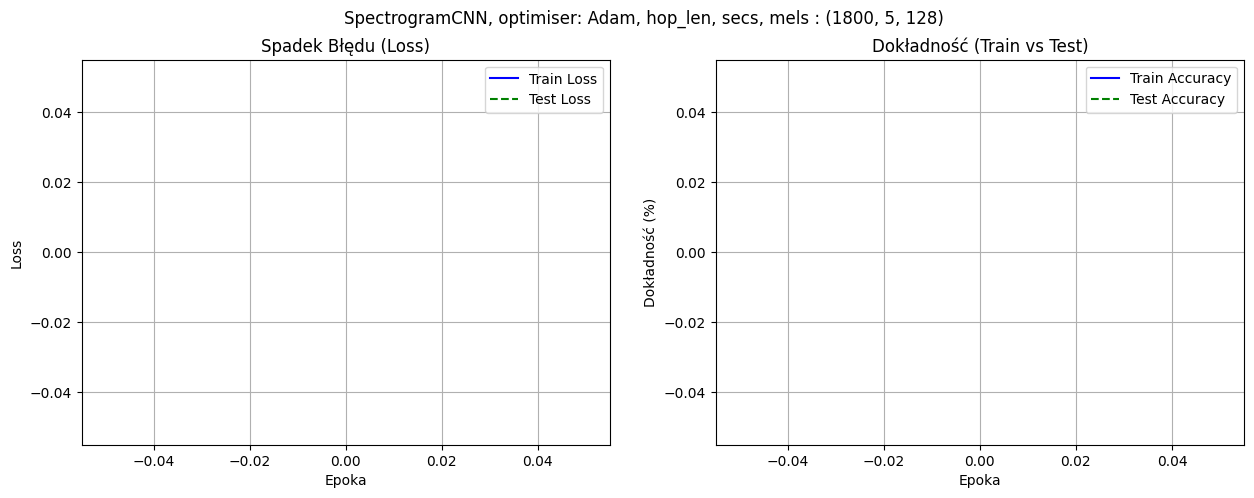


[KROK 4] Szczegółowy raport końcowy:


KeyboardInterrupt: 

In [143]:
model_training_and_eval(SpectrogramCNN, 
                        dataset=Mp3SpectrogramDataset, 
                        n_mels=128, 
                        seconds = 5, hop_len = 1800)

### 2.2 Standardowy CNN, hop_length = 400, n_mels = 128, 5 sekund

In [ ]:
model_training_and_eval(SpectrogramCNN, 
                        dataset=Mp3SpectrogramDataset, 
                        n_mels=128, 
                        seconds = 5, hop_len = 400)

### 2.3 Standardowy CNN, hop_length = 1800, n_mels = 128, 3 sekundy

In [ ]:
model_training_and_eval(SpectrogramCNN, 
                        dataset=Mp3SpectrogramDataset, 
                        n_mels=128, 
                        seconds = 4, hop_len = 1800)

### 2.4 Standardowy CNN, hop_length = 400, n_mels = 128, 3 sekundy

In [ ]:
model_training_and_eval(SpectrogramCNN, 
                        dataset=Mp3SpectrogramDataset, 
                        n_mels=128, 
                        seconds = 3, hop_len = 400)